# Mineração de Dados

## A Máquina de Enxugar Gelo

In [6]:
!python -m pip install pandas matplotlib seaborn scikit-learn numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import numpy as np

In [8]:
# 1. CARREGAMENTO DOS DADOS 
print("Carregando os arquivos CSV...")
df_edu = pd.read_csv('API_SE.XPD.TOTL.GD.ZS_DS2_en_csv_v2_115540.csv', skiprows=4)
df_sau = pd.read_csv('API_SH.XPD.GHED.GD.ZS_DS2_en_csv_v2_115647.csv', skiprows=4)
df_div = pd.read_csv('API_GC.XPN.INTP.RV.ZS_DS2_en_csv_v2_10000.csv', skiprows=4)

Carregando os arquivos CSV...


In [9]:
# 2. DEFINIÇÃO DA ANÁLISE 
anos_analise = ['2015', '2016', '2019', '2022'] # Anos variados para ver o Efeito Tesoura

paises_destaque = [
    'DEU', 'GBR', 'USA', 'FRA', 'CAN', 
    'IND', 'MEX', 'CHL', 'COL', 'TUR', 
    'BRA', 'ARG', 'EGY', 'ZAF', 'LBN'  
]


--- Processando o ano 2015 ---


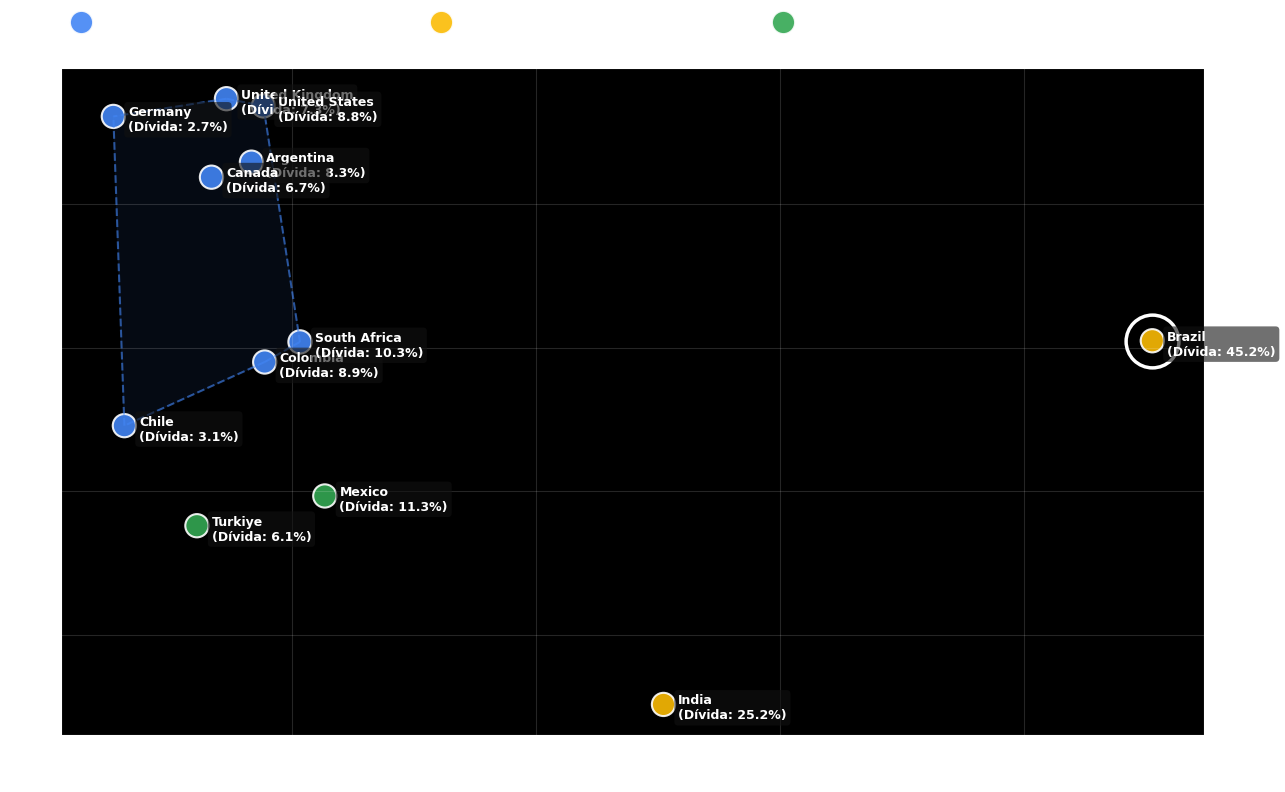


--- Processando o ano 2016 ---


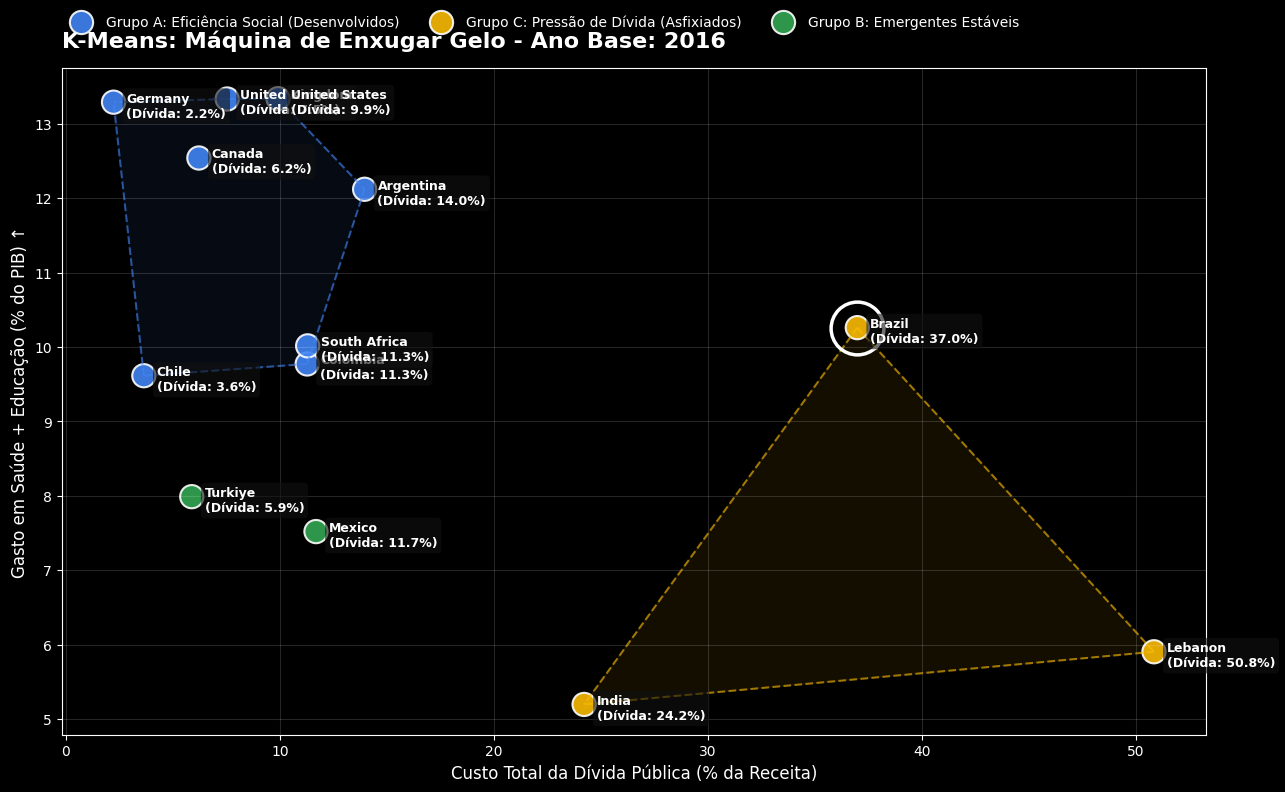


--- Processando o ano 2019 ---


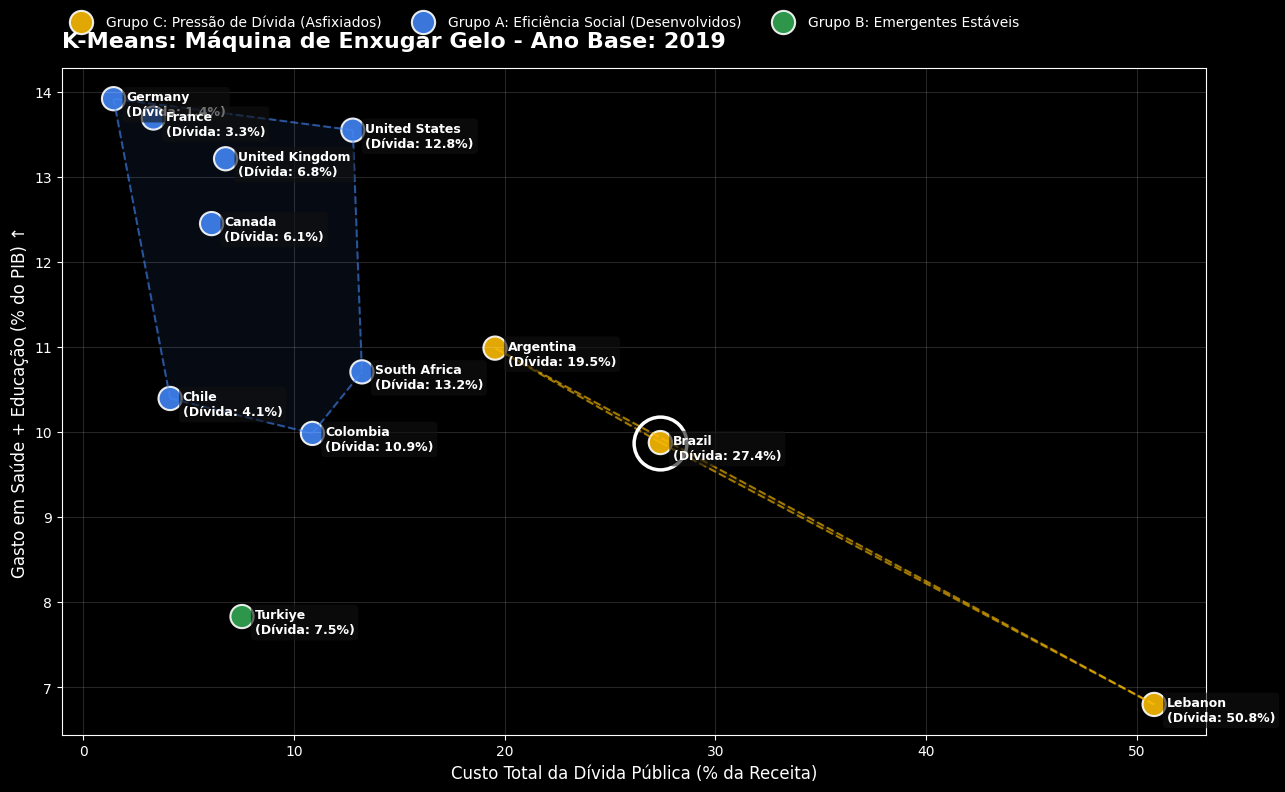


--- Processando o ano 2022 ---


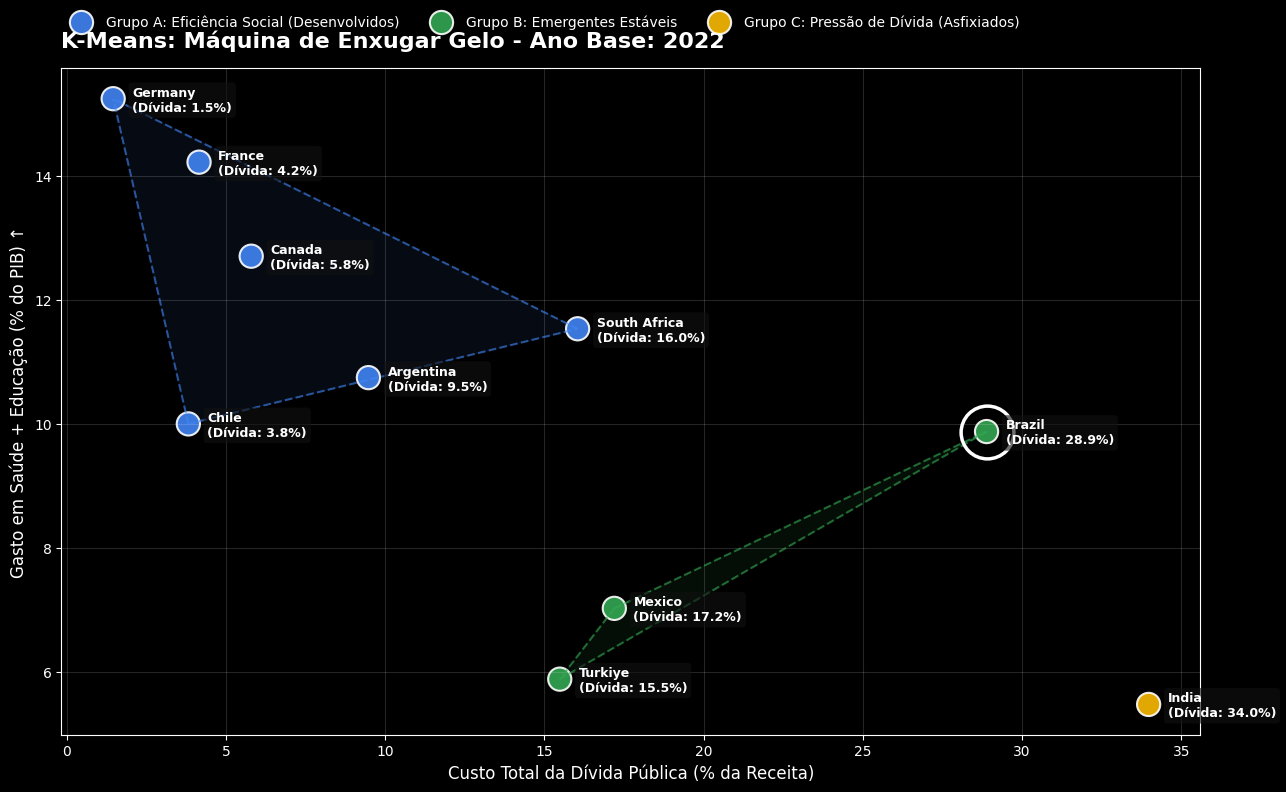

In [10]:
for ano in anos_analise:
    print(f"\n--- Processando o ano {ano} ---")
    
    # Extração dos dados do ano
    edu = df_edu[['Country Code', 'Country Name', ano]].rename(columns={ano: 'Educacao_PIB'})
    sau = df_sau[['Country Code', 'Country Name', ano]].rename(columns={ano: 'Saude_PIB'})
    div = df_div[['Country Code', 'Country Name', ano]].rename(columns={ano: 'Pagamento_Total_Divida'})
    
    # Merge global (O mundo inteiro)
    df_global = edu.merge(sau, on=['Country Code', 'Country Name'])
    df_global = df_global.merge(div, on=['Country Code', 'Country Name'])
    df_global['Gasto_Social'] = df_global['Educacao_PIB'] + df_global['Saude_PIB']
    
    # Limpeza Global: Remove apenas países que não têm dados nenhuns no ano
    df_global = df_global.dropna()
    
    if len(df_global) < 10:
        print(f"⚠️ O mundo não tem dados suficientes no Banco Mundial para {ano}. Pulando...")
        continue

    # 3. TREINAMENTO K-MEANS COM O MUNDO INTEIRO (Sem dar erro!)
    X = df_global[['Pagamento_Total_Divida', 'Gasto_Social']]
    scaler = StandardScaler()
    X_padronizado = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_global['Cluster_ID'] = kmeans.fit_predict(X_padronizado)

    # Identificação dos Clusters
    centroides = df_global.groupby('Cluster_ID')[['Pagamento_Total_Divida', 'Gasto_Social']].mean()
    id_desenvolvidos = centroides['Gasto_Social'].idxmax()
    id_asfixiados = centroides['Pagamento_Total_Divida'].idxmax()
    id_emergentes = [i for i in range(3) if i not in [id_desenvolvidos, id_asfixiados]][0]

    mapa_nomes = {
        id_desenvolvidos: 'Grupo A: Eficiência Social (Desenvolvidos)',
        id_emergentes: 'Grupo B: Emergentes Estáveis',
        id_asfixiados: 'Grupo C: Pressão de Dívida (Asfixiados)'
    }
    df_global['Nome_Cluster'] = df_global['Cluster_ID'].map(mapa_nomes)

    # 4. FILTRO APENAS PARA A APRESENTAÇÃO
    df_plot = df_global[df_global['Country Code'].isin(paises_destaque)].copy()
    
    if len(df_plot) < 3:
         print(f"⚠️ Dos 15 países escolhidos, só sobraram {len(df_plot)} com dados em {ano}. O gráfico não ficará bom.")
         continue

    # 5. VISUALIZAÇÃO
    plt.figure(figsize=(13, 8))
    plt.style.use('dark_background')
    
    cores = {
        'Grupo A: Eficiência Social (Desenvolvidos)': '#4285F4', 
        'Grupo B: Emergentes Estáveis': '#34A853',              
        'Grupo C: Pressão de Dívida (Asfixiados)': '#FBBC05'     
    }

    # Desenhando os polígonos
    for nome, grupo in df_plot.groupby('Nome_Cluster'):
        pontos = grupo[['Pagamento_Total_Divida', 'Gasto_Social']].values
        if len(pontos) >= 3:
            hull = ConvexHull(pontos)
            for simplex in hull.simplices:
                plt.plot(pontos[simplex, 0], pontos[simplex, 1], color=cores[nome], linestyle='--', linewidth=1.5, alpha=0.6)
            plt.fill(pontos[hull.vertices, 0], pontos[hull.vertices, 1], color=cores[nome], alpha=0.08)

    # Plotando os pontos
    sns.scatterplot(
        data=df_plot, x='Pagamento_Total_Divida', y='Gasto_Social', 
        hue='Nome_Cluster', palette=cores, s=280, alpha=0.9, edgecolor='white', linewidth=1.5
    )

    # Nomes e Números
    for i in range(df_plot.shape[0]):
        nome_pais = df_plot['Country Name'].iloc[i]
        val_x = df_plot['Pagamento_Total_Divida'].iloc[i]
        val_y = df_plot['Gasto_Social'].iloc[i]
        
        texto_etiqueta = f"{nome_pais}\n(Dívida: {val_x:.1f}%)"
        
        plt.annotate(
            texto_etiqueta, 
            (val_x + 0.6, val_y - 0.2),
            fontsize=9, color='white', fontweight='semibold',
            bbox=dict(boxstyle="round,pad=0.3", fc="#111111", alpha=0.6, ec="none") 
        )

    # Destacando o Brasil
    brasil_data = df_plot[df_plot['Country Code'] == 'BRA']
    if not brasil_data.empty:
        plt.plot(brasil_data['Pagamento_Total_Divida'].values[0], brasil_data['Gasto_Social'].values[0], 
                 'o', ms=38, mec='white', mfc='none', mew=2.5)

    plt.title(f'K-Means: Máquina de Enxugar Gelo - Ano Base: {ano}', fontsize=16, fontweight='bold', pad=15, loc='left')
    plt.xlabel('Custo Total da Dívida Pública (% da Receita)', fontsize=12)
    plt.ylabel('Gasto em Saúde + Educação (% do PIB) ↑', fontsize=12)
    plt.legend(bbox_to_anchor=(0, 1.05), loc='lower left', borderaxespad=0, ncol=3, frameon=False, fontsize=10)
    plt.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.show()